# Тема 2. Проверка связи частотного и классического определения вероятности с помощью моделирования
Приведите пример, показывающий связь частотного и классического определения вероятности с помощью моделирования (на примере задачи про красно-синие шары или задачи о сумме очков на двух кубиках). Графически показать стремление частотной вероятности к классической при увеличении числа опытов.
> Задача: вытаскивание карт из колоды без возвращения

> Условие: из покерной перетасованной колоды в $52$ карты (содержащей $4$ туза) наугад и без возвращения извлекаются $4$ карты.
Найти вероятность события $A$ — среди извлечённых $4$ карт есть хотя бы один туз.

In [49]:
import math
import matplotlib.pyplot as plt
import numpy as np

total_combinations = math.comb(52, 4)
no_ace_combinations = math.comb(48, 4)

theoretical_p = 1 - (no_ace_combinations / total_combinations)

print("Теоретическая вероятность P(A):", theoretical_p)

Теоретическая вероятность P(A): 0.2812632745405854


In [52]:
n_trials = 1000000

# вытягиваем 4 карты и получаем количество выпавших тузов
drawn_aces = np.random.hypergeometric(ngood=4, nbad=48, nsample=4, size=n_trials)

successes = drawn_aces >= 1

trials = np.arange(1, n_trials + 1)
relative_frequencies = np.cumsum(successes) / trials

print("Итоговая частотная вероятность:", relative_frequencies[-1])

Итоговая частотная вероятность: 0.28195


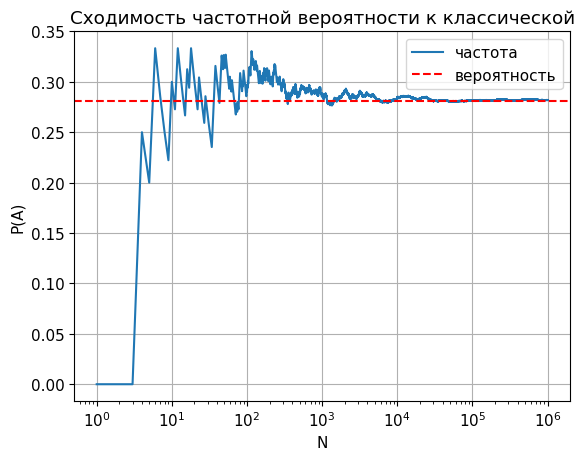

In [53]:
plt.plot(trials, relative_frequencies, label="частота")
plt.axhline(
    y=theoretical_p, color="r", linestyle="--", label="вероятность"
)

plt.xscale("log")
plt.xlabel("N")
plt.ylabel("P(A)")
plt.title("Сходимость частотной вероятности к классической")
plt.legend()
plt.grid(True)
plt.show()